<a href="https://colab.research.google.com/github/abrown12005/CMP_SC-4540-HW/blob/main/HW9/LFPSignalClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# File was too big for Github, so had to upload to google drive
# Upload the data file from the google drive
from google.colab import drive
drive.mount('/content/drive')

filepath = "/content/drive/MyDrive/Colab_Notebooks/Rat08Data/Rat08-20130711_017.h5"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Sampling rate: 1250.0 Hz


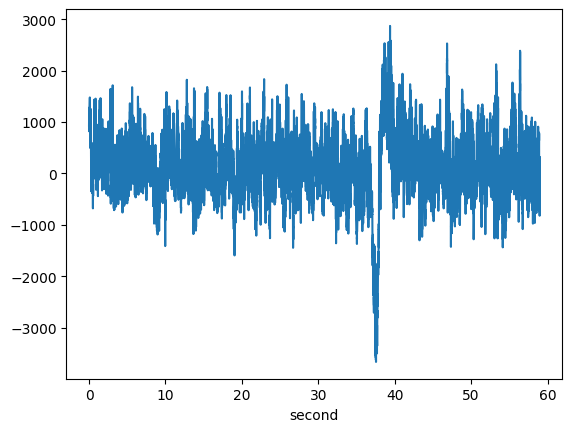

In [6]:
# Use the given Colab file to load and read the data
import h5py
import numpy as np

f = h5py.File(filepath, 'r')  # read data with h5 format
fs = f.attrs['fs'][0]  # get sampling frequency of LFP signal (Hz)
print("Sampling rate: %.1f Hz" % (fs))

states = []  # two states (NREM & WAKE) to be classified
# LFP recordings are store in two h5 groups for each state
# Under each h5 group, the LFP recordings are divided into several segments with different lengths.
for name, grp in f.items():
  states.append(name)
  #print("State: %s" % (name))
  #print("Segment IDs:")
  #print(list(grp.keys()))

# Convert the recording in to numpy arrays
# Use a dictionary to store the LFP recordings of the two states
# each containing a list of numpy arrays of all segments
lfp = {key: [] for key in states}
for key in states:
  group = f[key]  # h5 group of a state
  n = len(group)  # number of segments
  for i in range(n):
    lfp[key].append(group[str(i+1)][()].astype(float))  # convert data to numpy array and from int type to float type

#print(lfp)

# Visualizing the data
import matplotlib.pyplot as plt

x = lfp['NREM'][10]  # Visualize the LFP segment in NREM state
t = np.arange(x.size)/fs  # time points

plt.plot(t,x)
plt.xlabel('second')
plt.show()

In [7]:
# Cut, Format, and Normalize the data for the neural network
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Cutting function
def segment_by_time(data, duration_seconds, sampling_rate, overlap_seconds=0):

    clip_length = int(duration_seconds * sampling_rate)
    overlap = int(overlap_seconds * sampling_rate)
    step = clip_length - overlap

    X = []
    y = []
    label_map = {'NREM': 0, 'WAKE': 1}

    for sleep_stage, arrays in data.items():
        label = label_map[sleep_stage]

        for signal_array in arrays:
            # Calculate number of clips from this signal
            num_clips = (len(signal_array) - clip_length) // step + 1

            for i in range(num_clips):
                start_idx = i * step
                end_idx = start_idx + clip_length

                clip = signal_array[start_idx:end_idx]

                if len(clip) == clip_length:
                    X.append(clip)
                    y.append(label)

    return np.array(X), np.array(y)

# Convert to tensors
class TensorConv(Dataset):

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Perform the cutting and normalization
sampling_rate = fs
clip_duration = 5
overlap = 1.0
batch_size = 32
learning_rate = 0.001
epochs = 100

print("="*60)
print("DATA PREPARATION")
print("="*60)

# Segment the data
X, y = segment_by_time(
    lfp,
    duration_seconds=clip_duration,
    sampling_rate=sampling_rate,
    overlap_seconds=overlap
)

print(f"Sampling rate: {sampling_rate} Hz")
print(f"Clip duration: {clip_duration} seconds")
print(f"Samples per clip: {int(clip_duration * sampling_rate)}")
print(f"Total clips created: {len(X)}")
print(f"Clip shape: {X.shape}")
print(f"NREM clips: {np.sum(y==0)}, WAKE clips: {np.sum(y==1)}")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Normalize the data (using Min-Max or Z-score scaling)
scaler = StandardScaler()
minmax = MinMaxScaler()

#X_train_scaled = minmax.fit_transform(X_train)
#X_test_scaled = minmax.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create datasets and dataloaders
train_dataset = TensorConv(X_train_scaled, y_train)
test_dataset = TensorConv(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

DATA PREPARATION
Sampling rate: 1250.0 Hz
Clip duration: 5 seconds
Samples per clip: 6250
Total clips created: 4595
Clip shape: (4595, 6250)
NREM clips: 1544, WAKE clips: 3051

Train samples: 3676
Test samples: 919


In [8]:
# Now create the multi-layered neural network to classify the data

input_size = X_train.shape[1]

class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(MLP, self).__init__()

        # Build layers
        layers = []
        prev_size = input_size

        # Add hidden layers with ReLU activation
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size

        # Add the final output layer mapping to output_size
        layers.append(nn.Linear(prev_size, output_size))

        # Add Sigmoid activation
        layers.append(nn.Sigmoid())

        # Combine all layers into a sequential model
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Create the model
model = MLP(
    input_size=input_size,
    hidden_sizes=[32,15,10],
    output_size=1
)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Perform testing
train_losses = []
test_accuracies = []

for epoch in range(epochs):
    # Training
    model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:

        predictions = model(batch_X).squeeze()
        loss = criterion(predictions, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

    # Testing
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            predictions = model(batch_X).squeeze()
            predicted_labels = (predictions > 0.5).float()
            correct += (predicted_labels == batch_y).sum().item()
            total += batch_y.size(0)

    accuracy = correct / total *100
    test_accuracies.append(accuracy)

    if (epoch + 1) % 10 == 0:
          print(f"Epoch: [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")


Epoch: [10/100], Loss: 0.2837, Test Accuracy: 68.44%
Epoch: [20/100], Loss: 0.1655, Test Accuracy: 68.44%
Epoch: [30/100], Loss: 0.0616, Test Accuracy: 69.53%
Epoch: [40/100], Loss: 0.0724, Test Accuracy: 69.31%
Epoch: [50/100], Loss: 0.0359, Test Accuracy: 68.01%
Epoch: [60/100], Loss: 0.0982, Test Accuracy: 67.46%
Epoch: [70/100], Loss: 0.0263, Test Accuracy: 70.29%
Epoch: [80/100], Loss: 0.1017, Test Accuracy: 69.10%
Epoch: [90/100], Loss: 0.0209, Test Accuracy: 70.29%
Epoch: [100/100], Loss: 0.0201, Test Accuracy: 70.62%


One thing I found interesting about using this model was changing the amount of hidden nodes being used. I would have thought that the more hidden nodes and layers you have would lead to better results, but that isn't necessarily what I found. Not only does it take longer to run, but sometimes the accuracy would end up lower. In the future I wonder if there is a usual way people decide how many layers/nodes to use in their models, or if it is something that you just trial and error through. Something else I found that was as the loss goes down, the accuracy doesn't always get better which I found weird. I also noticed that the z-score normalization seemed to perform better than the min-max method.